In [1]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!mkdir kaggle_customer_churn
!kaggle datasets download -d blastchar/telco-customer-churn -p kaggle_customer_churn
!unzip kaggle_customer_churn/telco-customer-churn.zip -d kaggle_customer_churn

!ls kaggle_customer_churn

Saving kaggle.json to kaggle (4).json
mkdir: cannot create directory ‘kaggle_customer_churn’: File exists
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  kaggle_customer_churn/telco-customer-churn.zip
replace kaggle_customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: kaggle_customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv  
telco-customer-churn.zip  WA_Fn-UseC_-Telco-Customer-Churn.csv


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

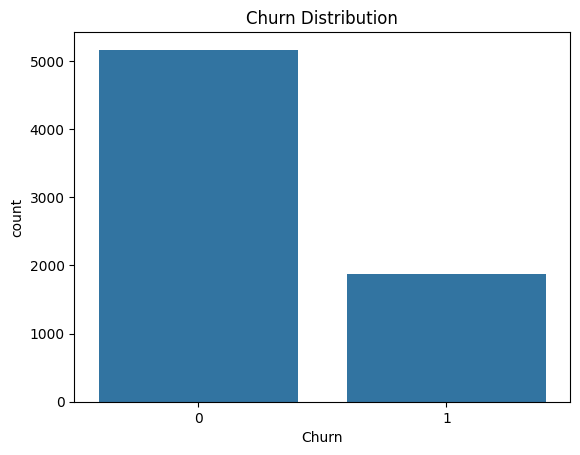

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

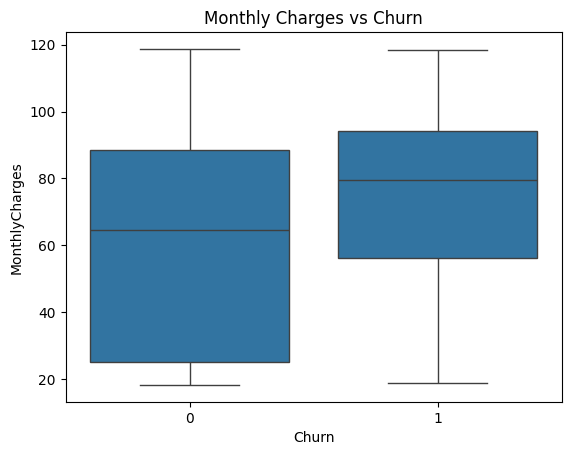

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

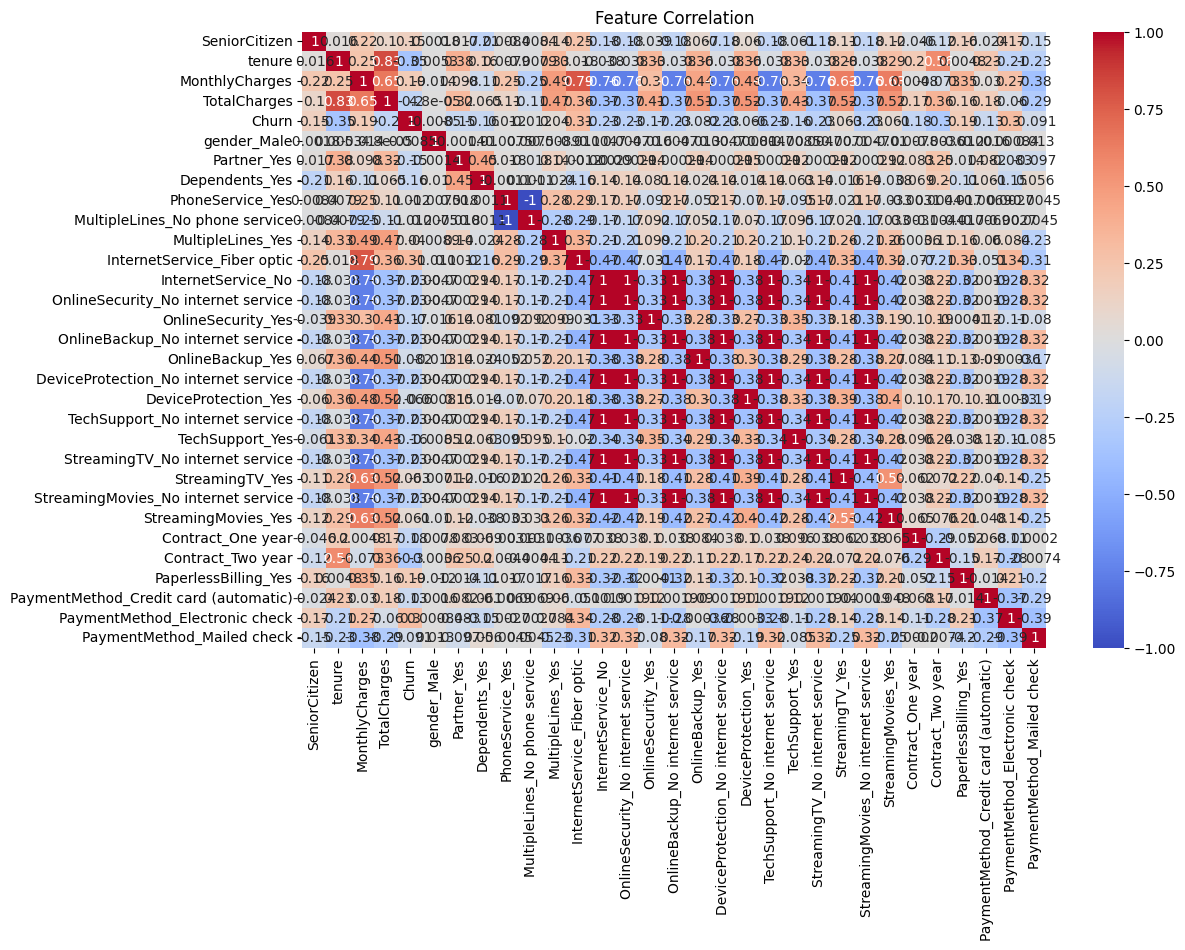

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Evaluation
Accuracy: 0.7874911158493249
Precision: 0.6205787781350482
Recall: 0.516042780748663

Confusion Matrix:
[[915 118]
 [181 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Decision tree Evaluation
Accuracy: 0.7249466950959488
Precision: 0.4838709677419355
Recall: 0.5213903743315508

Confusion Matrix:
[[825 208]
 [179 195]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.48      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.72      0.7

In [18]:
#Step 1: Import Libraries
#-------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("screenshots", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)


#Step 2: Load the Dataset
#---------------------------
df = pd.read_csv("kaggle_customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.info())


#Step 3: Data Cleaning
#-----------------------
#Handle Missing Values
print(df.isnull().sum())

df.dropna(inplace=True)

#Remove Unnecessary Columns
df.drop("customerID", axis=1, inplace=True)


#Step 4: Data Transformation
#----------------------------
#Convert Target Variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})



df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df.dropna(inplace=True)

# Apply OneHotEncoding
df = pd.get_dummies(df, drop_first=True)

# Display transformed dataset
print(df.head())

#Step 5: Exploratory Data Analysis (EDA)
#---------------------------------------
#Churn Distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.savefig("/content/screenshots/churn_distribution.png")
plt.show()

from google.colab import files
files.download("screenshots/churn_distribution.png")

#Monthly Charges vs Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.savefig(
    "/content/screenshots/monthly_charges_vs_churn.png"
)
plt.show()

from google.colab import files
files.download("screenshots/monthly_charges_vs_churn.png")



#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.savefig(
    "/content/screenshots/correlation_heatmap.png"
)
plt.show()


from google.colab import files
files.download("screenshots/correlation_heatmap.png")



#Step 6: Split the Dataset
#--------------------------
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



#Step 7: Model Building
#-------------------------
#Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)


#Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)


#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)



#Step 8: Model Evaluation
#---------------------------
#Logistic Regression Evaluation
print("Logistic Regression Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


#Decision tree Evaluation
print("Decision tree Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))



#Random forest Evaluation
print("Random forest Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))



# Step 9: Predict New Customer
# ------------------------------------

# Example:
# Create sample input using same columns as training data

sample_customer = X.iloc[0:5]

predictions = lr_model.predict(sample_customer)

for i, pred in enumerate(predictions):

    if pred == 1:
        print(f"Customer {i+1} is likely to churn")

    else:
        print(f"Customer {i+1} is likely to stay")